In [1]:
import pandas as pd
df = pd.read_csv('/content/sample_data/loan_approval_dataset.csv')
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [8]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# **EDA**

# Converting Object Dtype to Numerical Dtype

In [11]:
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    print(f"Unique values for '{col}': {df[col].unique()}")

Unique values for 'education': [' Graduate' ' Not Graduate']
Unique values for 'self_employed': [' No' ' Yes']
Unique values for 'loan_status': [' Approved' ' Rejected']


In [12]:
df['education'] = df['education'].apply(lambda x: 1 if x.strip() == 'Graduate' else 0)
df['self_employed'] = df['self_employed'].apply(lambda x: 1 if x.strip() == 'Yes' else 0)
df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x.strip() == 'Approved' else 0)

In [13]:
display(df.head())
df.info()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   int64
 3   self_employed             4269 non-null   int64
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   int64
dtypes: int64(13)
memory usage: 433.7 KB


# Removed unnecessary Feature

In [14]:
df = df.drop('loan_id', axis=1)
display(df.head())

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation of 'loan_status' with other features
print("Correlation of 'loan_status' with other features:\n", correlation_matrix['loan_status'].sort_values(ascending=False))

Correlation of 'loan_status' with other features:
 loan_status                 1.000000
cibil_score                 0.770518
loan_amount                 0.016150
commercial_assets_value     0.008246
education                   0.004918
self_employed               0.000345
bank_asset_value           -0.006778
residential_assets_value   -0.014367
income_annum               -0.015189
luxury_assets_value        -0.015465
no_of_dependents           -0.018114
loan_term                  -0.113036
Name: loan_status, dtype: float64


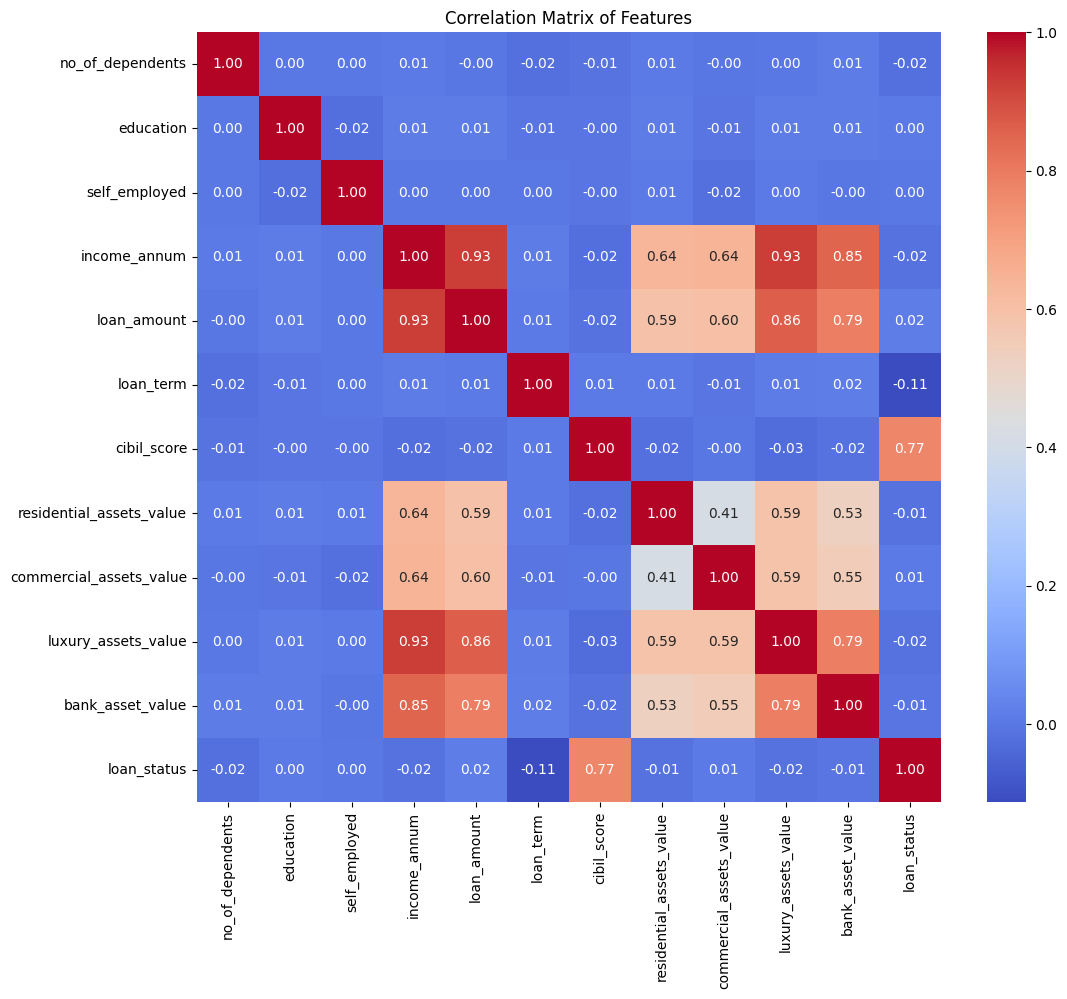

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

# Finding Noise

In [24]:
negative_residential_assets = df[df['residential_assets_value'] < 0]

if not negative_residential_assets.empty:
    print("Rows with negative 'residential_assets_value':")
    display(negative_residential_assets[['residential_assets_value']])
else:
    print("No negative values found in 'residential_assets_value'.")

Rows with negative 'residential_assets_value':


,residential_assets_value
59,-100000
196,-100000
559,-100000
702,-100000
737,-100000
784,-100000
904,-100000
1089,-100000
1163,-100000
1350,-100000


In [33]:
# Display specific columns for rows with negative 'residential_assets_value'
print("Selected columns for rows with negative 'residential_assets_value':")
display(negative_residential_assets[['income_annum', 'loan_amount', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value','loan_status']])

Selected columns for rows with negative 'residential_assets_value':


,income_annum,loan_amount,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
59,5500000,18200000,797,-100000,4900000,18600000,4800000,1
196,400000,1500000,669,-100000,600000,900000,500000,1
559,200000,500000,885,-100000,0,300000,200000,0
702,6300000,23900000,899,-100000,11400000,20600000,6700000,1
737,900000,2500000,458,-100000,100000,3200000,1100000,0
784,5000000,14400000,761,-100000,7300000,12600000,4500000,1
904,4100000,14900000,571,-100000,5200000,13000000,3400000,1
1089,5100000,11000000,336,-100000,5800000,11600000,7500000,0
1163,4500000,9100000,593,-100000,600000,12400000,2500000,1
1350,4000000,13700000,496,-100000,1400000,15800000,3700000,0


# Convert Noise as Null

In [34]:
import numpy as np

# Replace negative 'residential_assets_value' with None (NaN)
df.loc[df['residential_assets_value'] < 0, 'residential_assets_value'] = np.nan

# Display a sample of the modified rows to confirm
print("DataFrame after replacing negative 'residential_assets_value' with NaN (showing affected rows):")
display(df[df['residential_assets_value'].isna()])

DataFrame after replacing negative 'residential_assets_value' with NaN (showing affected rows):


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
59,4,0,1,5500000,18200000,16,797,NaN,4900000,18600000,4800000,1
196,4,0,1,400000,1500000,2,669,NaN,600000,900000,500000,1
559,2,1,1,200000,500000,6,885,NaN,0,300000,200000,0
702,4,1,1,6300000,23900000,6,899,NaN,11400000,20600000,6700000,1
737,2,1,1,900000,2500000,16,458,NaN,100000,3200000,1100000,0
784,0,1,0,5000000,14400000,2,761,NaN,7300000,12600000,4500000,1
904,2,1,0,4100000,14900000,12,571,NaN,5200000,13000000,3400000,1
1089,3,1,0,5100000,11000000,6,336,NaN,5800000,11600000,7500000,0
1163,2,1,0,4500000,9100000,18,593,NaN,600000,12400000,2500000,1
1350,5,1,0,4000000,13700000,6,496,NaN,1400000,15800000,3700000,0


In [35]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000.0,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000.0,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000.0,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000.0,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000.0,8200000,29400000,5000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000.0,500000,3300000,800000,0
4265,0,0,1,3300000,11300000,20,559,4200000.0,2900000,11000000,1900000,1
4266,2,0,0,6500000,23900000,18,457,1200000.0,12400000,18100000,7300000,0
4267,1,0,0,4100000,12800000,8,780,8200000.0,700000,14100000,5800000,1


# **Training Phase**

# > Train/Test Split

# > Replace the Null with Training data Median.(To avoid data leakage)

# > Creates X_Train_Scaled and X_Test_Scaled for Model that needs Scaling





















In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 2. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Find median ONLY from training data for 'residential_assets_value'
#    This will ignore NaN values by default when calculating the median
median_value = X_train['residential_assets_value'].median()

# 4. Replace NaN values in 'residential_assets_value' in BOTH datasets
#    using the SAME training median
X_train['residential_assets_value'] = X_train['residential_assets_value'].fillna(median_value)
X_test['residential_assets_value'] = X_test['residential_assets_value'].fillna(median_value)

# 5. Normal data is ready
# X_train, X_test → use for tree models

# 6. Scale the data for models that need scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training median used for imputation:", median_value)
print("Remaining NaN values in X_train['residential_assets_value'] after imputation:", X_train['residential_assets_value'].isna().sum())
print("Remaining NaN values in X_test['residential_assets_value'] after imputation:", X_test['residential_assets_value'].isna().sum())

Training median used for imputation: 5600000.0
Remaining NaN values in X_train['residential_assets_value'] after imputation: 0
Remaining NaN values in X_test['residential_assets_value'] after imputation: 0


# **Model_1 Logistic Regression**

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets and L1/L2 regularization
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Evaluate the model
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.91      0.91      0.91       854

Logistic Regression Accuracy: 0.9145


# Evaluation metrics

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log_reg)

print(cm)

[[281  42]
 [ 31 500]]


In [46]:
from sklearn.metrics import roc_auc_score

y_prob = log_reg_model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9726026598566873


In [47]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Probabilities of class 1 (Approved)
y_prob = log_reg_model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred_threshold
    ).ravel()

    print(f"\nThreshold: {threshold}")
    print(f"TN: {tn}")
    print(f"FP (False Approvals): {fp}")
    print(f"FN (False Rejections): {fn}")
    print(f"TP: {tp}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_threshold):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_threshold):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_threshold):.4f}")
    print(f"F1: {f1_score(y_test, y_pred_threshold):.4f}")


Threshold: 0.5
TN: 281
FP (False Approvals): 42
FN (False Rejections): 31
TP: 500
Accuracy: 0.9145
Precision: 0.9225
Recall: 0.9416
F1: 0.9320

Threshold: 0.55
TN: 287
FP (False Approvals): 36
FN (False Rejections): 36
TP: 495
Accuracy: 0.9157
Precision: 0.9322
Recall: 0.9322
F1: 0.9322

Threshold: 0.6
TN: 298
FP (False Approvals): 25
FN (False Rejections): 42
TP: 489
Accuracy: 0.9215
Precision: 0.9514
Recall: 0.9209
F1: 0.9359

Threshold: 0.65
TN: 302
FP (False Approvals): 21
FN (False Rejections): 52
TP: 479
Accuracy: 0.9145
Precision: 0.9580
Recall: 0.9021
F1: 0.9292

Threshold: 0.7
TN: 310
FP (False Approvals): 13
FN (False Rejections): 61
TP: 470
Accuracy: 0.9133
Precision: 0.9731
Recall: 0.8851
F1: 0.9270

Threshold: 0.75
TN: 313
FP (False Approvals): 10
FN (False Rejections): 71
TP: 460
Accuracy: 0.9052
Precision: 0.9787
Recall: 0.8663
F1: 0.9191

Threshold: 0.8
TN: 315
FP (False Approvals): 8
FN (False Rejections): 78
TP: 453
Accuracy: 0.8993
Precision: 0.9826
Recall: 0.8531
F

#  Hyperparameter Tuning

In [48]:
from sklearn.metrics import classification_report, accuracy_score

# Probabilities of class 1 (Approved)
y_prob = log_reg_model.predict_proba(X_test_scaled)[:, 1]

# Define the threshold
threshold = 0.6

# Apply the threshold to get binary predictions
y_pred_tuned = (y_prob >= threshold).astype(int)

print(f"--- Performance at Threshold: {threshold} ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_tuned):.4f}")

--- Performance at Threshold: 0.6 ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       323
           1       0.95      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.91      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854

Accuracy Score: 0.9215


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tuned)

print(cm)

[[298  25]
 [ 42 489]]


# **Model_2 K-Nearest Neighbor**

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the K-Nearest Neighbors model
# Starting with n_neighbors=5, a common default.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the model
print("K-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))
print(f"K-Nearest Neighbors Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       323
           1       0.91      0.93      0.92       531

    accuracy                           0.90       854
   macro avg       0.89      0.89      0.89       854
weighted avg       0.90      0.90      0.90       854

K-Nearest Neighbors Accuracy: 0.8958


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_knn)

print(cm)

[[272  51]
 [ 38 493]]


#  Hyperparameter Tuning

In [63]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = range(1, 21)

cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_scores.append(scores.mean())

    print(f"k={k}, CV Accuracy={scores.mean():.4f}")

# Find best k
best_k = k_values[np.argmax(cv_scores)]

print("\nBest k:", best_k)
print("Best CV Accuracy:", max(cv_scores))

k=1, CV Accuracy=0.8641
k=2, CV Accuracy=0.8542
k=3, CV Accuracy=0.8782
k=4, CV Accuracy=0.8741
k=5, CV Accuracy=0.8887
k=6, CV Accuracy=0.8873
k=7, CV Accuracy=0.8928
k=8, CV Accuracy=0.8966
k=9, CV Accuracy=0.9001
k=10, CV Accuracy=0.8984
k=11, CV Accuracy=0.9019
k=12, CV Accuracy=0.9022
k=13, CV Accuracy=0.9001
k=14, CV Accuracy=0.9042
k=15, CV Accuracy=0.8993
k=16, CV Accuracy=0.9028
k=17, CV Accuracy=0.9057
k=18, CV Accuracy=0.9083
k=19, CV Accuracy=0.9086
k=20, CV Accuracy=0.9098

Best k: 20
Best CV Accuracy: 0.9098096632503662


In [59]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)

knn_final.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=20)

In [60]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred_knn = knn_final.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.9098360655737705

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       323
           1       0.93      0.92      0.93       531

    accuracy                           0.91       854
   macro avg       0.90      0.91      0.90       854
weighted avg       0.91      0.91      0.91       854


Confusion Matrix:
[[289  34]
 [ 43 488]]


# **Model_3 Decision Tree**

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create Decision Tree
dt = DecisionTreeClassifier(
    random_state=42
)

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9824355971896955

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[315   8]
 [  7 524]]


In [65]:
print("Training Accuracy:", dt.score(X_train, y_train))
print("Test Accuracy:", dt.score(X_test, y_test))

Training Accuracy: 1.0
Test Accuracy: 0.9824355971896955


# Hyperparameter Tuning

In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Create the Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# 2. Parameters we want to test
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 3. GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Train
grid_search.fit(X_train, y_train)

# 5. Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}

Best CV Accuracy:
0.9803806734992679


In [67]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Best Decision Tree
best_dt = grid_search.best_estimator_

# Prediction
y_pred_dt = best_dt.predict(X_test)

# Accuracy
print("Decision Tree Test Accuracy:",
      accuracy_score(y_test, y_pred_dt))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Test Accuracy: 0.9824355971896955

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[313  10]
 [  5 526]]


In [68]:
print("Training Accuracy:", best_dt.score(X_train, y_train))
print("Test Accuracy:", best_dt.score(X_test, y_test))

Training Accuracy: 0.9932650073206443
Test Accuracy: 0.9824355971896955


# Feature Importance

In [69]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                     Feature  Importance
6                cibil_score    0.771646
5                  loan_term    0.132739
4                loan_amount    0.043937
3               income_annum    0.022810
8    commercial_assets_value    0.016502
9        luxury_assets_value    0.004724
7   residential_assets_value    0.004421
0           no_of_dependents    0.003221
1                  education    0.000000
2              self_employed    0.000000
10          bank_asset_value    0.000000


# dataset has an extremely strong relationship between CIBIL score and loan status

In [70]:
import pandas as pd

df['cibil_range'] = pd.cut(
    df['cibil_score'],
    bins=[0, 500, 600, 650, 700, 750, 800, 900],
    labels=[
        '<500',
        '500-599',
        '600-649',
        '650-699',
        '700-749',
        '750-799',
        '800+'
    ]
)

cibil_analysis = df.groupby('cibil_range', observed=False)['loan_status'].agg(
    total='count',
    approved='sum',
    approval_rate='mean'
)

print(cibil_analysis)

             total  approved  approval_rate
cibil_range                                
<500          1406       150       0.106686
500-599        738       392       0.531165
600-649        333       333       1.000000
650-699        367       363       0.989101
700-749        372       371       0.997312
750-799        362       359       0.991713
800+           691       688       0.995658


In [71]:
print("Minimum CIBIL:", df['cibil_score'].min())
print("Maximum CIBIL:", df['cibil_score'].max())

print("\nAverage CIBIL by loan status:")
print(df.groupby('loan_status')['cibil_score'].mean())

Minimum CIBIL: 300
Maximum CIBIL: 900

Average CIBIL by loan status:
loan_status
0    429.468072
1    703.461973
Name: cibil_score, dtype: float64


# **Model_4 Random Forest**

In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Accuracy
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9812646370023419

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[314   9]
 [  7 524]]
Training Accuracy: 1.0
Test Accuracy: 0.9812646370023419


In [81]:
print("Training Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Training Accuracy: 1.0
Test Accuracy: 0.9812646370023419


# Hyperparameter Tuning

# Don't Try to Run this,It will take 10 mins to run

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_rf.best_params_)

print("\nBest CV Accuracy:")
print(grid_search_rf.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

Best CV Accuracy:
0.9806734992679356


In [77]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest Test Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Test Accuracy: 0.9824355971896955

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[314   9]
 [  6 525]]


In [78]:
print("Training Accuracy:", best_rf.score(X_train, y_train))
print("Test Accuracy:", best_rf.score(X_test, y_test))

Training Accuracy: 0.9970717423133236
Test Accuracy: 0.9824355971896955


# **Model_5 Naive Bayes**

In [82]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create Gaussian Naive Bayes
nb = GaussianNB()

# Train
nb.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb.predict(X_test_scaled)

# Accuracy
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9484777517564403

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       323
           1       0.96      0.96      0.96       531

    accuracy                           0.95       854
   macro avg       0.95      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854


Confusion Matrix:
[[301  22]
 [ 22 509]]


# **Why did Naive Bayes perform worse?**

# The main reason is its independence assumption.

# Naive Bayes basically assumes that, once we know the loan status, the features are independent of each other.

# But your data has relationships between features.

# cibil_score has an extremely strong relationship with loan_status.

# **Model_6 SVM**

In [83]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create SVM
svm = SVC(
    kernel='rbf',
    random_state=42
)

# Train
svm.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm.predict(X_test_scaled)

# Accuracy
print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.9414519906323185

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       323
           1       0.96      0.95      0.95       531

    accuracy                           0.94       854
   macro avg       0.94      0.94      0.94       854
weighted avg       0.94      0.94      0.94       854


Confusion Matrix:
[[300  23]
 [ 27 504]]


# Cross Validation

In [84]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm = SVC(random_state=42)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest CV Accuracy:")
print(grid_svm.best_score_)

Best Parameters:
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

Best CV Accuracy:
0.9443631039531478


In [85]:
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

print("SVM Test Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Test Accuracy: 0.9484777517564403

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       323
           1       0.96      0.96      0.96       531

    accuracy                           0.95       854
   macro avg       0.95      0.94      0.95       854
weighted avg       0.95      0.95      0.95       854


Confusion Matrix:
[[299  24]
 [ 20 511]]


# **Model_7 Gradient Boosting Classifier**

In [86]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)

# Train
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Accuracy
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, y_pred_gb))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9812646370023419

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[313  10]
 [  6 525]]


# Cross Validation

In [87]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best Parameters:")
print(grid_gb.best_params_)

print("\nBest CV Accuracy:")
print(grid_gb.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best CV Accuracy:
0.9853587115666178


In [88]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

print("Gradient Boosting Test Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Test Accuracy: 0.9859484777517564

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.98      0.99       854
weighted avg       0.99      0.99      0.99       854


Confusion Matrix:
[[316   7]
 [  5 526]]


In [89]:
print("Training Accuracy:", best_gb.score(X_train, y_train))
print("Test Accuracy:", best_gb.score(X_test, y_test))

Training Accuracy: 1.0
Test Accuracy: 0.9859484777517564


So yes, the Gradient Boosting model is fitting the training data perfectly, but the gap is only:

1.41 percentage points.

# **Model_8 XGBoost**

In [90]:
pip install xgboost

In [91]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Accuracy
print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9847775175644028

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[314   9]
 [  4 527]]


# Cross Validation

In [92]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest CV Accuracy:")
print(grid_xgb.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}

Best CV Accuracy:
0.9833089311859444


In [93]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("XGBoost Test Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nTraining Accuracy:",
      best_xgb.score(X_train, y_train))

print("Test Accuracy:",
      best_xgb.score(X_test, y_test))

XGBoost Test Accuracy: 0.9859484777517564

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.98      0.99       854
weighted avg       0.99      0.99      0.99       854


Confusion Matrix:
[[315   8]
 [  4 527]]

Training Accuracy: 0.9991215226939971
Test Accuracy: 0.9859484777517564


# As a ML engineer you need to think in a Important banking perspective

Gradient Boosting and XGBoost have the same accuracy, but their mistakes are slightly different.

Gradient Boosting:

False approvals = 7
False rejections = 5

XGBoost:

False approvals = 8
False rejections = 4

If your main concern is avoiding bad loans being approved, then false approvals are particularly important, so Gradient Boosting has a slight advantage here.

If your main concern is not rejecting good customers, XGBoost has a slight advantage.

Model_9 LightGBM

In [94]:
pip install lightgbm

In [95]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create LightGBM
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

# Train
lgbm.fit(X_train, y_train)

# Predict
y_pred_lgbm = lgbm.predict(X_test)

# Accuracy
print("LightGBM Accuracy:",
      accuracy_score(y_test, y_pred_lgbm))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

LightGBM Accuracy: 0.9847775175644028

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[316   7]
 [  6 525]]


# Hyperparameter Tuning

In [96]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

lgbm = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

param_grid_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [15, 31, 50],
    'max_depth': [-1, 5, 10]
}

grid_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lgbm.fit(X_train, y_train)

print("Best Parameters:")
print(grid_lgbm.best_params_)

print("\nBest CV Accuracy:")
print(grid_lgbm.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 50}

Best CV Accuracy:
0.9865300146412885


In [97]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

best_lgbm = grid_lgbm.best_estimator_

y_pred_lgbm = best_lgbm.predict(X_test)

print("LightGBM Test Accuracy:",
      accuracy_score(y_test, y_pred_lgbm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

print("\nTraining Accuracy:",
      best_lgbm.score(X_train, y_train))

print("Test Accuracy:",
      best_lgbm.score(X_test, y_test))

LightGBM Test Accuracy: 0.9836065573770492

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[316   7]
 [  7 524]]

Training Accuracy: 1.0
Test Accuracy: 0.9836065573770492


# **Model_10 catBoost**

In [98]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [99]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create CatBoost
cat = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

# Train
cat.fit(X_train, y_train)

# Predict
y_pred_cat = cat.predict(X_test)

# Accuracy
print("CatBoost Accuracy:",
      accuracy_score(y_test, y_pred_cat))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cat))

CatBoost Accuracy: 0.9789227166276346

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[312  11]
 [  7 524]]


# Hyperparameter Tuning

In [100]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

cat = CatBoostClassifier(
    random_seed=42,
    verbose=0
)

param_grid_cat = {
    'iterations': [100, 200],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

grid_cat = GridSearchCV(
    estimator=cat,
    param_grid=param_grid_cat,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_cat.fit(X_train, y_train)

print("Best Parameters:")
print(grid_cat.best_params_)

print("\nBest CV Accuracy:")
print(grid_cat.best_score_)

Best Parameters:
{'depth': 6, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

Best CV Accuracy:
0.9830161054172766


In [101]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

best_cat = grid_cat.best_estimator_

y_pred_cat = best_cat.predict(X_test)

print("CatBoost Test Accuracy:",
      accuracy_score(y_test, y_pred_cat))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cat))

print("\nTraining Accuracy:",
      best_cat.score(X_train, y_train))

print("Test Accuracy:",
      best_cat.score(X_test, y_test))

CatBoost Test Accuracy: 0.9812646370023419

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


Confusion Matrix:
[[315   8]
 [  8 523]]

Training Accuracy: 0.9991215226939971
Test Accuracy: 0.9812646370023419


| Model                | Test Accuracy |
| -------------------- | ------------: |
| 🥇 Gradient Boosting |    **98.59%** |
| 🥇 XGBoost           |    **98.59%** |
| LightGBM             |        98.36% |
| Decision Tree        |        98.24% |
| Random Forest        |        98.24% |
| CatBoost             |        98.13% |
| Naive Bayes          |        94.85% |
| SVM                  |        94.85% |
| Logistic Regression  |        92.15% |
| KNN                  |        90.98% |


# **Model_11 Stacking**

# Stacking using your three strongest models

# Gradient Boosting, XGBoost, and Random Forest

In [102]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Base models
gb = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    n_estimators=100,
    random_state=42
)

xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=1,
    n_estimators=100,
    subsample=1.0,
    random_state=42,
    eval_metric='logloss'
)

rf = RandomForestClassifier(
    criterion='entropy',
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Stacking model
stacking_model = StackingClassifier(
    estimators=[
        ('gb', gb),
        ('xgb', xgb),
        ('rf', rf)
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# Train
stacking_model.fit(X_train, y_train)

# Predict
y_pred_stack = stacking_model.predict(X_test)

# Results
print("Stacking Accuracy:",
      accuracy_score(y_test, y_pred_stack))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))

Stacking Accuracy: 0.9871194379391101

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854


Confusion Matrix:
[[316   7]
 [  4 527]]


# **Model_12 Blending**

In [106]:
# Fit the three base models

gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("All three models fitted successfully!")

All three models fitted successfully!


In [107]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Get probabilities for class 1 (Approved)
gb_prob = gb.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]

# Equal-weight blending
blend_prob = (
    gb_prob +
    xgb_prob +
    rf_prob
) / 3

# Convert probability to class
y_pred_blend = (blend_prob >= 0.5).astype(int)

# Results
print("Blending Accuracy:",
      accuracy_score(y_test, y_pred_blend))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_blend))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_blend))

Blending Accuracy: 0.9871194379391101

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854


Confusion Matrix:
[[316   7]
 [  4 527]]


In [108]:
from sklearn.metrics import accuracy_score

# =========================
# TRAINING PROBABILITIES
# =========================

gb_train_prob = gb.predict_proba(X_train)[:, 1]
xgb_train_prob = xgb.predict_proba(X_train)[:, 1]
rf_train_prob = rf.predict_proba(X_train)[:, 1]

# Equal-weight blending
train_blend_prob = (
    gb_train_prob +
    xgb_train_prob +
    rf_train_prob
) / 3

# Convert probability to class
y_train_blend = (train_blend_prob >= 0.5).astype(int)

# =========================
# TESTING PROBABILITIES
# =========================

gb_test_prob = gb.predict_proba(X_test)[:, 1]
xgb_test_prob = xgb.predict_proba(X_test)[:, 1]
rf_test_prob = rf.predict_proba(X_test)[:, 1]

# Equal-weight blending
test_blend_prob = (
    gb_test_prob +
    xgb_test_prob +
    rf_test_prob
) / 3

# Convert probability to class
y_test_blend = (test_blend_prob >= 0.5).astype(int)

# =========================
# ACCURACY
# =========================

train_accuracy = accuracy_score(y_train, y_train_blend)
test_accuracy = accuracy_score(y_test, y_test_blend)

print("Blending Training Accuracy:", train_accuracy)
print("Blending Test Accuracy:", test_accuracy)

Blending Training Accuracy: 0.9997071742313324
Blending Test Accuracy: 0.9871194379391101


# Best individual models and the ensemble

In [109]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "Random Forest": rf
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    print(f"\n{name}")
    print("CV Scores:", scores)
    print("Mean CV Accuracy:", scores.mean())
    print("Std:", scores.std())


Gradient Boosting
CV Scores: [0.98535871 0.9897511  0.9795022  0.98682284 0.98535871]
Mean CV Accuracy: 0.9853587115666178
Std: 0.0033387274527060997

XGBoost
CV Scores: [0.98828697 0.98682284 0.97364568 0.98682284 0.98096633]
Mean CV Accuracy: 0.9833089311859444
Std: 0.005446874154535341

Random Forest
CV Scores: [0.98389458 0.98535871 0.97218155 0.98389458 0.97803807]
Mean CV Accuracy: 0.9806734992679356
Std: 0.004934787568478107


| Model                | Mean CV Accuracy |   Std Dev | Test Accuracy |
| -------------------- | ---------------: | --------: | ------------: |
| 🥇 Gradient Boosting |       **98.54%** | **0.33%** |        98.59% |
| XGBoost              |           98.33% |     0.54% |        98.59% |
| Random Forest        |           98.07% |     0.49% |        98.24% |


# **check leakage before trusting the 98.71% ensemble score**


> Check whether loan_status accidentally exists in X.

> Check duplicate rows.

> Check whether train/test contain duplicates of each other.

> Check feature-target relationships for suspiciously perfect predictors.

> Check whether preprocessing was fitted after the split.

> Check whether your residential_assets_value median was calculated only from training data.

> Check whether the dataset contains an ID/index-like column.

> Check whether loan_status appears to be directly generated from one or more features.

In [110]:
import pandas as pd
import numpy as np

print("========== 1. TARGET LEAKAGE ==========")

print("Target column in X_train:",
      'loan_status' in X_train.columns)

print("Target column in X_test:",
      'loan_status' in X_test.columns)


print("\n========== 2. DUPLICATES ==========")

print("Duplicate rows in full dataset:",
      df.duplicated().sum())

print("Duplicate rows in X_train:",
      X_train.duplicated().sum())

print("Duplicate rows in X_test:",
      X_test.duplicated().sum())


print("\n========== 3. TRAIN/TEST OVERLAP ==========")

# Convert rows to comparable tuples
train_rows = set(map(tuple, X_train.to_numpy()))
test_rows = set(map(tuple, X_test.to_numpy()))

overlap = train_rows.intersection(test_rows)

print("Identical feature rows appearing in both train and test:",
      len(overlap))


print("\n========== 4. CONSTANT / NEAR-CONSTANT FEATURES ==========")

for col in X_train.columns:

    unique_count = X_train[col].nunique()
    print(f"{col}: {unique_count} unique values")


print("\n========== 5. CORRELATION WITH TARGET ==========")

corr = df.corr(numeric_only=True)['loan_status'] \
        .sort_values(ascending=False)

print(corr)

========== 1. TARGET LEAKAGE ==========
Target column in X_train: False
Target column in X_test: False

========== 2. DUPLICATES ==========
Duplicate rows in full dataset: 0
Duplicate rows in X_train: 0
Duplicate rows in X_test: 0

========== 3. TRAIN/TEST OVERLAP ==========
Identical feature rows appearing in both train and test: 0

========== 4. CONSTANT / NEAR-CONSTANT FEATURES ==========
no_of_dependents: 6 unique values
education: 2 unique values
self_employed: 2 unique values
income_annum: 98 unique values
loan_amount: 370 unique values
loan_term: 10 unique values
cibil_score: 599 unique values
residential_assets_value: 272 unique values
commercial_assets_value: 188 unique values
luxury_assets_value: 379 unique values
bank_asset_value: 145 unique values

========== 5. CORRELATION WITH TARGET ==========
loan_status                 1.000000
cibil_score                 0.770518
loan_amount                 0.016150
commercial_assets_value     0.008246
education                   0.00

# **Model Trained using ONLY CIBIL_score.**

In [111]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Only CIBIL
X_cibil_train = X_train[['cibil_score']]
X_cibil_test = X_test[['cibil_score']]

cibil_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

cibil_model.fit(X_cibil_train, y_train)

cibil_pred = cibil_model.predict(X_cibil_test)

print("CIBIL-only Accuracy:",
      accuracy_score(y_test, cibil_pred))

print("\nClassification Report:")
print(classification_report(y_test, cibil_pred))

CIBIL-only Accuracy: 0.9660421545667447

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       323
           1       0.99      0.95      0.97       531

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.96       854
weighted avg       0.97      0.97      0.97       854



# **Model Trained using NO CIBIL_score.**

In [112]:
# Remove CIBIL from the features

X_train_no_cibil = X_train.drop(columns=['cibil_score'])
X_test_no_cibil = X_test.drop(columns=['cibil_score'])

print("Original features:", X_train.shape[1])
print("Without CIBIL:", X_train_no_cibil.shape[1])

Original features: 11
Without CIBIL: 10


In [113]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_no_cibil = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=1,
    n_estimators=100,
    random_state=42
)

gb_no_cibil.fit(X_train_no_cibil, y_train)

y_pred_no_cibil = gb_no_cibil.predict(X_test_no_cibil)

print("Gradient Boosting WITHOUT CIBIL")
print("Accuracy:",
      accuracy_score(y_test, y_pred_no_cibil))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_no_cibil))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_no_cibil))

Gradient Boosting WITHOUT CIBIL
Accuracy: 0.5936768149882904

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.16      0.23       323
           1       0.63      0.85      0.72       531

    accuracy                           0.59       854
   macro avg       0.52      0.51      0.48       854
weighted avg       0.54      0.59      0.54       854


Confusion Matrix:
[[ 53 270]
 [ 77 454]]


| Experiment        |   Accuracy |
| ----------------- | ---------: |
| **CIBIL only**    | **96.60%** |
| **All features**  | **98.71%** |
| **Without CIBIL** | **59.37%** |


# CIBIL-only model already gets 96.60%, and your full model gets 98.71%.

# CIBIL → strongest signal → ensemble adds ~2.1 percentage points → 98.71%.

# **ROC-AUC for Blending**

In [114]:
from sklearn.metrics import roc_auc_score

blend_auc = roc_auc_score(y_test, blend_prob)

print("Blending ROC-AUC:", blend_auc)

Blending ROC-AUC: 0.9988513990193163


# **ROC-AUC for Stacking**

In [115]:
stack_prob = stacking_model.predict_proba(X_test)[:, 1]

stack_auc = roc_auc_score(y_test, stack_prob)

print("Stacking ROC-AUC:", stack_auc)

Stacking ROC-AUC: 0.9988630599429781


# **Compare them**

In [116]:
print("================================")
print("FINAL ENSEMBLE COMPARISON")
print("================================")

print("Stacking Accuracy :", accuracy_score(y_test, y_pred_stack))
print("Blending Accuracy :", accuracy_score(y_test, y_pred_blend))

print("Stacking ROC-AUC  :", stack_auc)
print("Blending ROC-AUC  :", blend_auc)

FINAL ENSEMBLE COMPARISON
Stacking Accuracy : 0.9871194379391101
Blending Accuracy : 0.9871194379391101
Stacking ROC-AUC  : 0.9988630599429781
Blending ROC-AUC  : 0.9988513990193163


# **🏆 Final model: Stacking**

I'd select Stacking as your final model because:

*   Accuracy = 98.71%
*   ROC-AUC = 0.99886
*   Only 7 false approvals
*   Only 4 false rejections
*   It slightly beats blending in ROC-AUC.
*   It learns how to combine the base models instead of relying on a fixed average.

In [117]:
import joblib

# Save the final stacking model
joblib.dump(stacking_model, "stacking_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [118]:
import os

print(os.path.exists("stacking_model.pkl"))

True


In [122]:
joblib.dump(median_value, "residential_assets_median.pkl")

['residential_assets_median.pkl']

In [125]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print(feature_names)

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [126]:
print(X_train.columns.tolist())

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [127]:
import xgboost, sklearn, joblib

print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

XGBoost: 3.3.0
Scikit-learn: 1.6.1
Joblib: 1.5.3
